Combined shape: (1604, 85)
condition
CD         738
UC         447
healthy    419
Name: count, dtype: int64


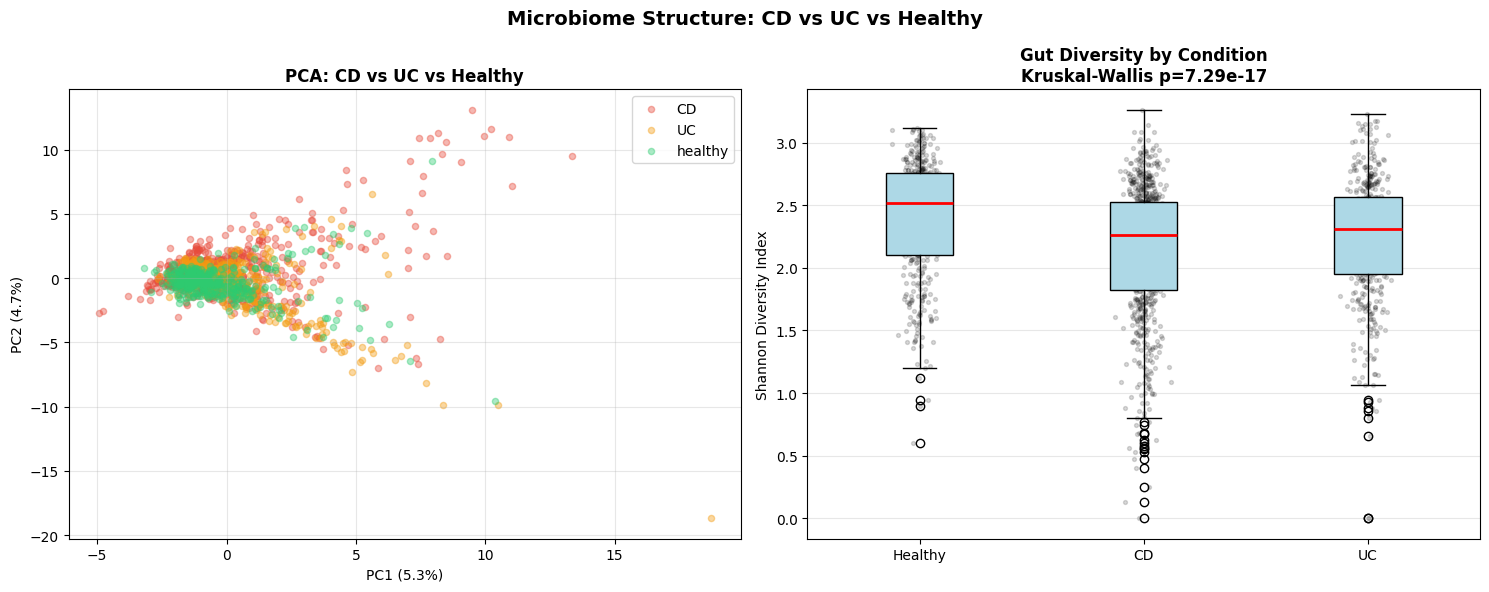

Figure 1 saved


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import kruskal

net_sp = pd.read_csv("../data/processed/MASTER_network_species.csv", header=None)[0].tolist()

cd = pd.read_csv("../data/processed/CD_network.csv", index_col=0)
uc = pd.read_csv("../data/processed/UC_network.csv", index_col=0)
healthy = pd.read_csv("../data/processed/healthy_network.csv", index_col=0)

cd['condition'] = 'CD'
uc['condition'] = 'UC'
healthy['condition'] = 'healthy'

combined = pd.concat([cd, uc, healthy]).reset_index(drop=True)

features = combined[net_sp]
labels = combined['condition']

print("Combined shape:", combined.shape)
print(labels.value_counts())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

colors = {'CD': '#e74c3c', 'UC': '#f39c12', 'healthy': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for cond in ['CD', 'UC', 'healthy']:
    mask = (labels == cond).values
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=colors[cond], label=cond,
               alpha=0.4, s=20)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA: CD vs UC vs Healthy", fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

def shannon(row):
    p = row[row > 0].values
    return -np.sum(p * np.log(p + 1e-10))

cd_norm = pd.read_csv("../data/processed/CD_normalized.csv", index_col=0)
uc_norm = pd.read_csv("../data/processed/UC_normalized.csv", index_col=0)
h_norm = pd.read_csv("../data/processed/healthy_normalized.csv", index_col=0)

cd_sh = cd_norm.apply(shannon, axis=1)
uc_sh = uc_norm.apply(shannon, axis=1)
h_sh = h_norm.apply(shannon, axis=1)

stat, pval = kruskal(cd_sh, uc_sh, h_sh)

ax = axes[1]

ax.boxplot([h_sh, cd_sh, uc_sh],
           tick_labels=['Healthy', 'CD', 'UC'],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))

for i, data in enumerate([h_sh, cd_sh, uc_sh], start=1):
    x = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.15, s=8, color='black')

ax.set_ylabel("Shannon Diversity Index")
ax.set_title(f"Gut Diversity by Condition\nKruskal-Wallis p={pval:.2e}",
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle("Microbiome Structure: CD vs UC vs Healthy",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../figures/final/Fig1_EDA.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure 1 saved")